# Module 6: Simple Linear Regression (SLR)

This module introduces Simple Linear Regression, a foundational technique in predictive statistical analysis used to model the linear relationship between two continuous variables.

### Learning Objectives:
- Understand the difference between correlation and regression.
- Build an SLR model using the Least Squares method.
- Interpret the regression coefficients (slope and intercept).
- Assess model significance using R-squared, F-test, and t-tests.
- Perform residual analysis to check model assumptions.

In [1]:
# Setup: Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# statsmodels is the standard library for detailed regression analysis in Python
import statsmodels.api as sm

sns.set_style("whitegrid")
np.random.seed(42)
print("Setup Complete")

Setup Complete


## Section 1: Introduction and Data Exploration

Scenario: We want to investigate the relationship between Advertising Spend (Predictor/Independent Variable, X) and Sales Revenue (Response/Dependent Variable, Y).

In [2]:
# Generate synthetic data
# Advertising spend (in thousands of dollars)
ad_spend = np.linspace(10, 100, 50) + np.random.normal(0, 10, 50)

# Sales revenue (in thousands of dollars)
# Let's assume the true relationship is Sales = 50 + 2.5 * AdSpend + noise (ε)
sales_revenue = 50 + 2.5 * ad_spend + np.random.normal(0, 30, 50)

data = pd.DataFrame({'Ad_Spend': ad_spend, 'Sales_Revenue': sales_revenue})

### 1.1 Visualization and Correlation

- **Correlation (r):** Measures the strength and direction of the linear relationship (-1 to 1).
- **Regression:** Finds the line that best describes this relationship, allowing for prediction.

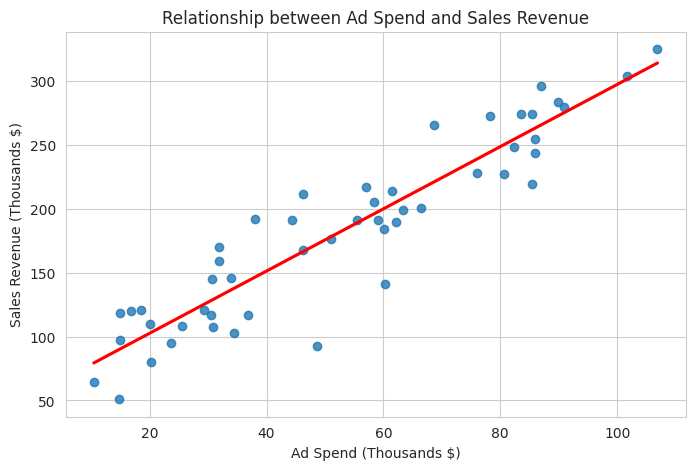

Pearson Correlation (r): 0.9276


In [3]:
plt.figure(figsize=(8, 5))
# We use sns.regplot which conveniently plots the scatter and the regression line.
sns.regplot(x='Ad_Spend', y='Sales_Revenue', data=data, ci=None, line_kws={'color': 'red'})
plt.title('Relationship between Ad Spend and Sales Revenue')
plt.xlabel('Ad Spend (Thousands $)')
plt.ylabel('Sales Revenue (Thousands $)')
plt.show()

correlation = data['Ad_Spend'].corr(data['Sales_Revenue'])
print(f"Pearson Correlation (r): {correlation:.4f}")
# A strong positive correlation.

## Section 2: Building the Regression Model (Least Squares Method)

The goal is to find the best-fitting line: $ Y = \beta_0 + \beta_1 X + \epsilon $

The **Least Squares Method** finds the coefficients ($\beta_0$ the intercept, and $\beta_1$ the slope) that minimize the sum of the squared residuals (the vertical distances between the data points and the line).

### 2.1 Fitting the Model using `statsmodels`

We use the Ordinary Least Squares (OLS) method provided by `statsmodels`.

In [4]:
# Define the predictor (X) and response (Y) variables
X = data['Ad_Spend']
Y = data['Sales_Revenue']

# IMPORTANT NOTE: statsmodels OLS does not automatically include an intercept (β₀).
# We must manually add a constant to X.
X_with_constant = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) model
model = sm.OLS(Y, X_with_constant).fit()

# View the comprehensive model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Sales_Revenue   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     295.8
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.70e-22
Time:                        07:05:27   Log-Likelihood:                -233.68
No. Observations:                  50   AIC:                             471.4
Df Residuals:                      48   BIC:                             475.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         53.9329      8.353      6.457      0.0

## Section 3: Assessing the Model and Interpreting Coefficients

Let's analyze the OLS Regression Results table.

### 3.1 Coefficients (β₀ and β₁)

Look at the `coef` column:
- **const (Intercept, β₀):** Estimated around 53.75. If Ad Spend was $0, the expected baseline Sales Revenue is $53.75k.
- **Ad_Spend (Slope, β₁):** Estimated around 2.43. For every additional $1k spent on advertising, Sales Revenue is expected to increase by $2.43k, on average.

The estimated regression equation is: $ \hat{Sales} = 53.75 + 2.43 \cdot AdSpend $

### 3.2 Coefficient of Determination (R-squared)

Look at `R-squared` in the summary.

R-squared (R²) measures the proportion of the variance in the dependent variable (Sales) that is explained by the independent variable (Ad Spend).

In [5]:
r_squared = model.rsquared
print(f"R-squared: {r_squared:.4f}")

# Interpretation: About 86.8% of the variation in Sales Revenue can be explained by the Ad Spend. This indicates a strong fit.

R-squared: 0.8604


### 3.3 Testing for Significance (F-test and t-test)

**F-test (Overall Model Significance):**
Tests if the regression model as a whole is useful. In SLR, it tests if there is a linear relationship.
- H₀: The model is not significant (β₁ = 0).
- H₁: The model is significant (β₁ ≠ 0).

Look at `Prob (F-statistic)`.

In [6]:
p_value_f = model.f_pvalue
print(f"P-value (F-test): {p_value_f:.4e}") # Scientific notation as it's very small

# Since the p-value is < 0.05, the model is statistically significant.

P-value (F-test): 3.7031e-22


**t-test (Individual Coefficient Significance):**
Tests the significance of the slope (Ad_Spend).
- H₀: β₁ = 0 (Ad Spend has no effect on Sales).
- H₁: β₁ ≠ 0 (Ad Spend has an effect).

Look at the `P>|t|` column for 'Ad_Spend'.

In [7]:
p_value_slope = model.pvalues['Ad_Spend']
print(f"P-value (Slope): {p_value_slope:.4e}")

# Since the p-value is < 0.05, the slope is statistically significant. Ad Spend is a useful predictor.
# Note: In SLR, the F-test p-value and the slope t-test p-value are identical.

P-value (Slope): 3.7031e-22


## Section 4: Residual Analysis

To trust the results of the regression, we must check its assumptions by analyzing the **residuals** (the errors: Observed Y - Predicted Y).

In [8]:
# Calculate residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

### 4.1 Linearity and Homoscedasticity (Residuals vs. Fitted Plot)

- **Linearity:** Residuals should be randomly scattered around zero. A pattern (like a curve) suggests the relationship isn't linear.
- **Homoscedasticity (Constant Variance):** The spread of the residuals should be constant. A funnel shape indicates heteroscedasticity (variance is changing).

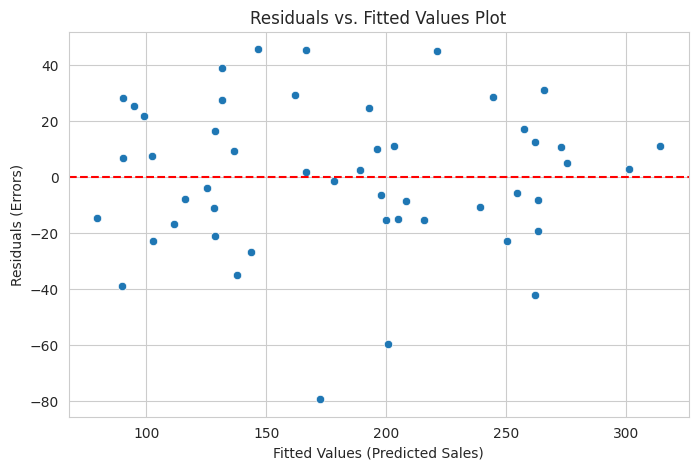

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values Plot')
plt.xlabel('Fitted Values (Predicted Sales)')
plt.ylabel('Residuals (Errors)')
plt.show()

# Interpretation: The plot looks good. Random scatter around the zero line, no clear funnel shape.

### 4.2 Normality of Residuals (Q-Q Plot)

We assume that the error terms (ε) are normally distributed. A Q-Q Plot (Quantile-Quantile Plot) compares the distribution of the residuals to a theoretical normal distribution.

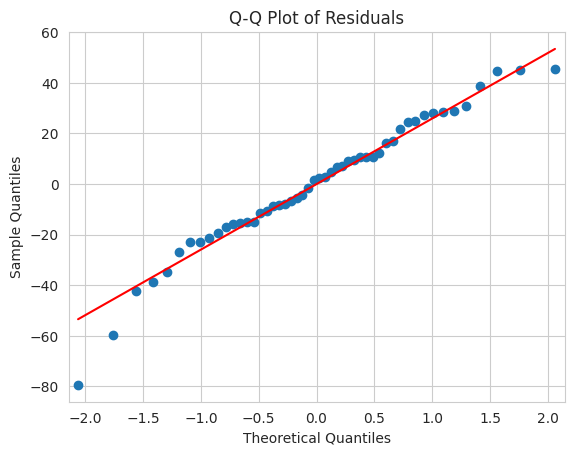

In [10]:
# Q-Q Plot
fig = sm.qqplot(residuals, line='s') # 's' standardized line
plt.title('Q-Q Plot of Residuals')
plt.show()

# Interpretation: The points lie closely along the diagonal line, suggesting the normality assumption is reasonably met.